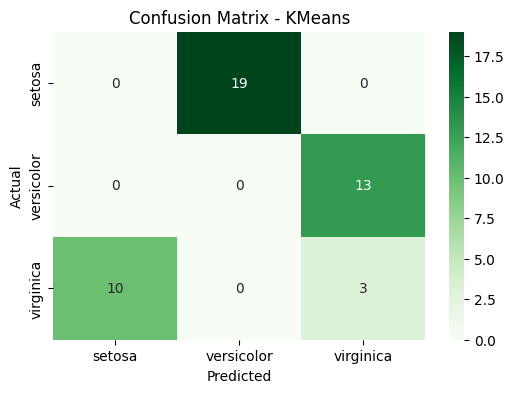

Classification Report               precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.00      0.00      0.00        13
           2       0.19      0.23      0.21        13

    accuracy                           0.07        45
   macro avg       0.06      0.08      0.07        45
weighted avg       0.05      0.07      0.06        45



In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = KMeans(n_clusters=3, random_state=42)
model.fit(X_train)

pred = model.predict(X_test)

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Greens",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KMeans")
plt.show()

print("Classification Report", classification_report(y_test,pred))

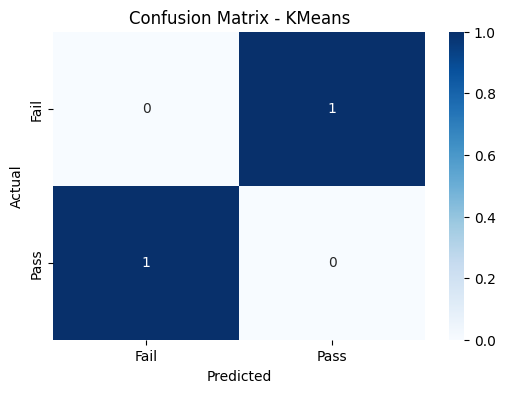

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Read CSV file
data = pd.read_csv("student_marks.csv")

# Features (marks)
X = data[['Math','Science','English']].values

# Target (Pass/Fail)
y = data['Result'].values

# Convert Pass/Fail → 1/0
le = LabelEncoder()
y = le.fit_transform(y)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# KMeans Model (2 clusters for Pass and Fail)
model = KMeans(n_clusters=2, random_state=42)
model.fit(X_train)

# Prediction
pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KMeans")
plt.show()

# Classification Report
print("Classification Report")
print(classification_report(y_test, pred))